# Grover's Algorithm — 10-Qubit Implementation
### Quantum Computing Course Project
**Author:** Pawan Joshi


## Objective

Implement Grover's search algorithm from scratch using Qiskit to find two marked states in a **10-qubit search space** ($2^{10} = 1024$ states).

| Parameter | Value |
|---|---|
| Search space | $2^{10} = 1024$ states |
| Marked states | `"0110011010"` and `"1101010001"` |
| Oracle | Custom-built, no built-in Grover |

**Tasks:**
1. Uniform superposition via Hadamard gates.
2. Oracle that phase-flips marked states.
3. Grover diffusion operator.
4. Run for $k = 1, 3, 5, 10$, and optimal.
5. Execute on Aer simulator (≥ 1024 shots) with histograms.


---
## Background

Classical search: $O(N)$ queries. Grover's: $O(\sqrt{N})$ — **quadratic speedup**.

$$|0\rangle^{\otimes n} \xrightarrow{H^{\otimes n}} |s\rangle \xrightarrow{(U_f \cdot U_s)^k} |\text{marked}\rangle$$

**Optimal iterations:** $k_{\text{opt}} = \lfloor \pi / (4\theta) \rfloor$ where $\theta = \arcsin\sqrt{M/N}$.


---
## Mathematical Framework

**Oracle:** $U_f = I - 2|\omega\rangle\langle\omega|$ — open-control X gates + MCZ.

**Diffuser:** $U_s = H^{\otimes n}(2|0\rangle\langle 0| - I)H^{\otimes n}$ — $X^{\otimes n} \to \text{MCZ} \to X^{\otimes n}$.


---
## Setup & Imports

In [ ]:
# ── Standard library ──
import math

# ── Qiskit ──
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import MCMTGate, ZGate   # used in IBM-style oracle only
from qiskit.visualization import plot_histogram

# ── Qiskit Aer (local simulator) ──
from qiskit_aer import Aer

# ── Utilities ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("All imports successful ✓")


All imports successful ✓


---
## Problem Setup

| Item | Value |
|---|---|
| Qubits | 10 |
| Total states | 1024 |
| Marked states | `"0110011010"`, `"1101010001"` |
| Optimal $k$ | 17 |
| Shots | 8192 |


In [ ]:
# ── Problem parameters ──
N_QUBITS    = 10
targets = ["0110011010", "1101010001"]   # as specified in the project
N_SHOTS         = 8192

# ── Derived quantities ──
N     = 2 ** N_QUBITS          # total search space
M     = len(targets)       # number of marked states
theta = math.asin(math.sqrt(M / N))
k_optimal = math.floor(math.pi / (4 * theta))

# ── Iteration counts to study (as required by the project spec) ──
k_list = [1, 3, 5, 10, k_optimal]   # 1, 3, 5, 10 + optimal

print(f"Number of qubits  : {N_QUBITS}")
print(f"Search space size : 2^{N_QUBITS} = {N}")
print(f"Marked states ({M}) :")
for s in targets:
    print(f"  '{s}'  →  decimal {int(s, 2):<5}")

print(f"\nθ = arcsin(√(M/N)) = arcsin(√({M}/{N})) = {theta:.6f} rad")
print(f"k_optimal = ⌊π / (4θ)⌋ = ⌊{math.pi/(4*theta):.4f}⌋ = {k_optimal}")
print(f"\nIteration counts to study: {k_list}")

print(f"\n{'k':>5}  {'P(marked) theory':>18}")
print("─" * 27)
for k in k_list:
    p = math.sin((2*k + 1)*theta)**2
    flag = " ← optimal" if k == k_optimal else ""
    print(f"{k:>5}  {p:>18.4f}{flag}")


Number of qubits  : 10
Search space size : 2^10 = 1024
Marked states (2) :
  '0110011010'  →  decimal 410  
  '1101010001'  →  decimal 849  

θ = arcsin(√(M/N)) = arcsin(√(2/1024)) = 0.044209 rad
k_optimal = ⌊π / (4θ)⌋ = ⌊17.7657⌋ = 17

Iteration counts to study: [1, 3, 5, 10, 17]

    k    P(marked) theory
───────────────────────────
    1              0.0175
    3              0.0927
    5              0.2184
   10              0.6410
   17              0.9994 ← optimal


---
---
# Section 1 — Oracle Construction

- **Part A:** IBM-style oracle — `MCMTGate(ZGate(), ...)`
- **Part B:** Phase-kickback oracle — `mcx` into ancilla $|{-}\rangle$

Neither uses `qiskit.algorithms.Grover`.


---
## Part A — IBM-Style Oracle

Uses `MCMTGate(ZGate(), n-1, 1)` with open-control X-gates.


In [3]:
def build_oracle(targets):
    """
    Grover oracle — IBM documentation subroutine.

    Applies a −1 phase to each state listed in targets by using:
      1. X gates on qubits where the target bit-string has '0'  (open-control trick)
      2. MCMTGate(ZGate(), n−1, 1)  — multi-controlled-Z on all n qubits
      3. X gates again to restore qubit values

    Parameters
    ----------
    targets : str or list of str
        Binary string(s) to phase-flip.  All must have the same length.

    Returns
    -------
    QuantumCircuit
        n-qubit oracle circuit.
    """
    if not isinstance(targets, list):
        targets = [targets]

    n_qbits = len(targets[0])
    qc = QuantumCircuit(n_qbits, name='Oracle A\n(IBM-style)')

    for target in targets:
        # Qiskit uses little-endian qubit ordering → reverse the bit-string
        rev_tgt = target[::-1]

        # Qubits where the target has '0' need an X gate (open-control trick)
        zero_positions = [i for i in range(n_qbits) if rev_tgt[i] == '0']

        if zero_positions:
            qc.x(zero_positions)              # flip '0' qubits to |1⟩

        # Multi-Controlled-Z: phase flip only when ALL qubits are |1⟩
        qc.compose(MCMTGate(ZGate(), n_qbits - 1, 1), inplace=True)

        if zero_positions:
            qc.x(zero_positions)              # restore the flipped qubits

    return qc


Oracle A (IBM-style)
  Qubits     : 10
  Depth      : 6
  Gate count : OrderedDict({'x': 20, 'mcmt': 2})
  Marks      : ['0110011010', '1101010001']


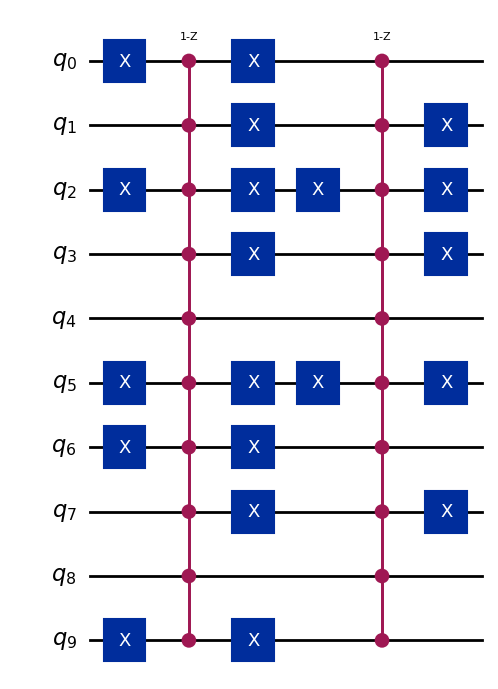

In [ ]:
# ── Build and inspect the Part A oracle ──
oracle_ibm = build_oracle(targets)

print(f"Oracle A (IBM-style)")
print(f"  Qubits     : {oracle_ibm.n_qbits}")
print(f"  Depth      : {oracle_ibm.depth()}")
print(f"  Gate count : {oracle_ibm.count_ops()}")
print(f"  Marks      : {targets}")

oracle_ibm.draw(output='mpl', style='iqp', fold=60)


---
---
# Section 2 — Diffusion Operator

$$U_s = H^{\otimes n} \cdot U_0 \cdot H^{\otimes n}$$

Implementation: $X^{\otimes n} \to \text{MCZ} \to X^{\otimes n}$ where $\text{MCZ} = H_{n-1} \cdot \text{MCX} \cdot H_{n-1}$.


In [ ]:
def build_diff_circuit(n_qbits):
    """
    Grover diffusion operator — inversion about the mean.

    Implements U_s = H^n · U_0 · H^n  where U_0 = (2|0><0| − I).

    Full gate sequence:
        H^⊗n  →  X^⊗n  →  H_{n-1}  →  MCX(0..n-2 → n-1)  →  H_{n-1}  →  X^⊗n  →  H^⊗n

    The inner  H · MCX · H  block implements a Multi-Controlled-Z (MCZ) gate
    using only the primitive MCX (multi-controlled-X / generalised Toffoli).

    Parameters
    ----------
    n_qbits : int
        Number of data qubits (same as the oracle).

    Returns
    -------
    QuantumCircuit
        n_qbits-qubit diff_circuit circuit.
    """
    qc = QuantumCircuit(n_qbits, name='Diffuser')

    # ── 1. H^⊗n : rotate to Hadamard basis ──
    qc.h(range(n_qbits))
    qc.barrier(label='H⊗n')

    # ── 2. X^⊗n : flip all qubits so |0…0⟩ → |1…1⟩ ──
    qc.x(range(n_qbits))
    qc.barrier(label='X⊗n')

    # ── 3. MCZ = H · MCX · H on last qubit ──
    #    Putting H on qubit n-1 before and after an MCX converts the
    #    bit-flip target into a phase-flip target, effectively making MCZ.
    qc.h(n_qbits - 1)
    qc.mcx(list(range(n_qbits - 1)), n_qbits - 1)
    qc.h(n_qbits - 1)
    qc.barrier(label='MCZ')

    # ── 4. X^⊗n : restore all qubits ──
    qc.x(range(n_qbits))
    qc.barrier(label='X⊗n')

    # ── 5. H^⊗n : rotate back to computational basis ──
    qc.h(range(n_qbits))

    return qc


Grover Diffuser (manual)
  Qubits     : 10
  Depth      : 7
  Gate count : OrderedDict({'h': 22, 'x': 20, 'barrier': 4, 'mcx': 1})


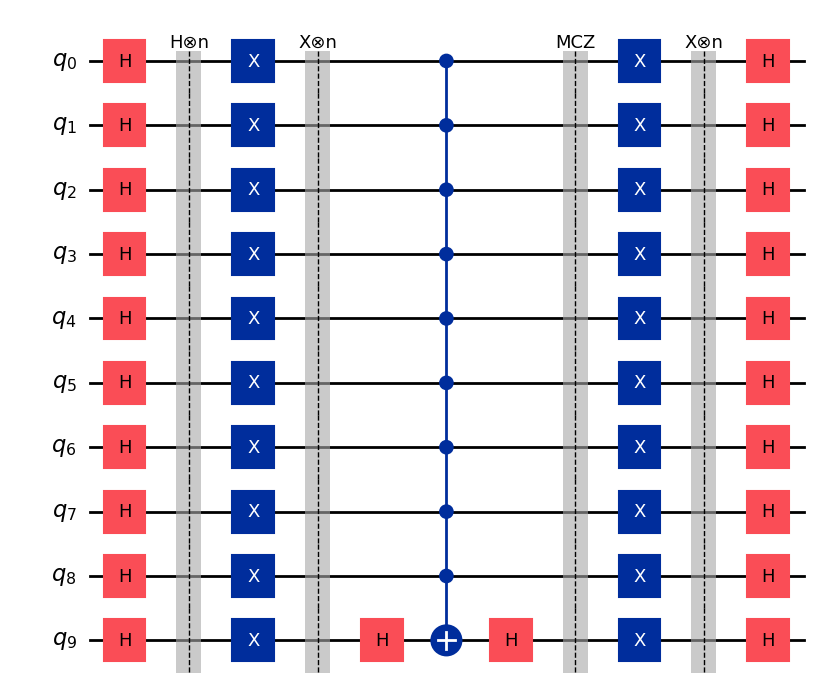

In [ ]:
# ── Build and inspect the diff_circuit ──
diff_circuit = build_diff_circuit(N_QUBITS)

print(f"Grover Diffuser (manual)")
print(f"  Qubits     : {diff_circuit.n_qbits}")
print(f"  Depth      : {diff_circuit.depth()}")
print(f"  Gate count : {diff_circuit.count_ops()}")

diff_circuit.draw(output='mpl', style='iqp', fold=60)


---
---
# Section 3 — Phase Kickback Oracle (Part B)

Ancilla initialised in $|{-}\rangle = (|0\rangle-|1\rangle)/\sqrt{2}$. MCX on ancilla kicks back $-1$ phase:

$$X|{-}\rangle = -|{-}\rangle$$


In [ ]:
def build_oracle_kickback(targets):
    """
    Custom Grover oracle using Phase Kickback.

    Uses (n + 1) qubits:
      - Qubits 0 … n−1  :  data register (n = N_QUBITS)
      - Qubit n          :  ancilla qubit (initialised and returned to |0⟩)

    Per marked state:
      ┌──────────────────────────────────────────────────────────────────┐
      │  Prepare ancilla:  |0⟩ ──X──H──▶ |−⟩                             │
      │  For each marked state ω:                                        │
      │    1. X on qubits where ω has '0'   (open-control trick)         │
      │    2. MCX(data qubits → ancilla)    (kicks back −1 phase)        │
      │    3. X on same qubits              (undo open controls)         │
      │  Uncompute ancilla:  |−⟩ ──H──X──▶ |0⟩                           │
      └──────────────────────────────────────────────────────────────────┘

    Parameters
    ----------
    targets : str or list of str
        Binary string(s) to phase-flip.

    Returns
    -------
    QuantumCircuit
        (n+1)-qubit circuit; ancilla starts and ends in |0⟩.
    """
    if not isinstance(targets, list):
        targets = [targets]

    n_qbits = len(targets[0])
    ancilla    = n_qbits          # ancilla qubit index

    qc = QuantumCircuit(n_qbits + 1, name='Oracle B\n(Kickback)')

    # ── 1. Prepare ancilla in |−⟩ ──
    qc.x(ancilla)          # |0⟩ → |1⟩
    qc.h(ancilla)          # |1⟩ → |−⟩ = (|0⟩ − |1⟩)/√2
    qc.barrier(label='anc |−⟩')

    # ── 2. Phase-flip each marked state via kickback ──
    for target in targets:
        rev_tgt = target[::-1]          # little-endian ordering

        # Indices where target bit is '0' → need temporary X flip
        zero_positions = [i for i in range(n_qbits) if rev_tgt[i] == '0']

        if zero_positions:
            qc.x(zero_positions)                # open-control: flip '0' bits

        # MCX: all data qubits → ancilla
        # When data == |ω⟩, MCX flips |−⟩ → −|−⟩  →  −1 kicks back to data
        qc.mcx(list(range(n_qbits)), ancilla)

        if zero_positions:
            qc.x(zero_positions)                # undo temporary flips

        qc.barrier(label=f'|{target}⟩')

    # ── 3. Uncompute ancilla back to |0⟩ ──
    qc.h(ancilla)          # |−⟩ → |1⟩
    qc.x(ancilla)          # |1⟩ → |0⟩

    return qc


Oracle B (Phase Kickback)
  Qubits (data + ancilla) : 11
  Depth                   : 10
  Gate count              : OrderedDict({'x': 22, 'barrier': 3, 'h': 2, 'mcx': 2})
  Ancilla qubit index     : 10  (unmeasured; returns to |0⟩)


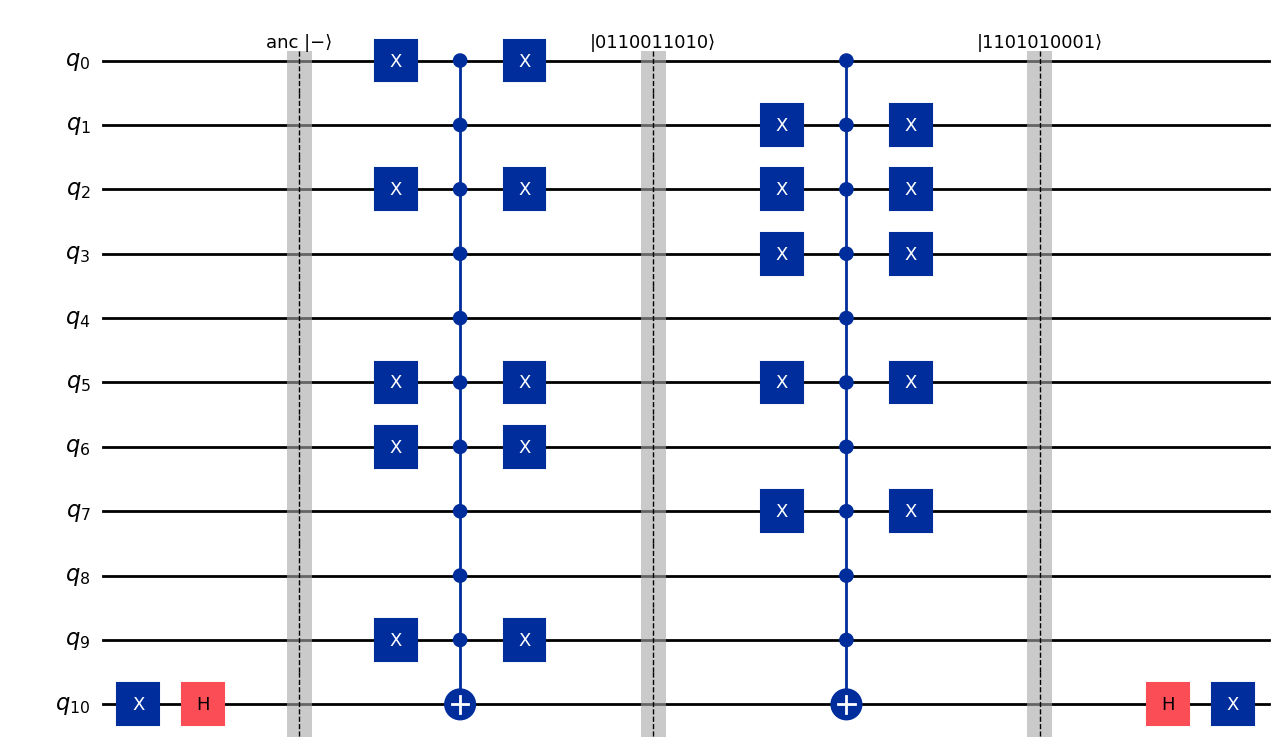

In [ ]:
# ── Build and inspect the Part B oracle ──
oracle_kb = build_oracle_kickback(targets)

print(f"Oracle B (Phase Kickback)")
print(f"  Qubits (data + ancilla) : {oracle_kb.n_qbits}")
print(f"  Depth                   : {oracle_kb.depth()}")
print(f"  Gate count              : {oracle_kb.count_ops()}")
print(f"  Ancilla qubit index     : {N_QUBITS}  (unmeasured; returns to |0⟩)")

oracle_kb.draw(output='mpl', style='iqp', fold=60)


---
---
# Section 4 — Grover Circuit Builder

Assembles: $|0\rangle^n \to H^{\otimes n} \to [\text{Oracle} \cdot \text{Diffuser}]^k \to \text{Measure}$


In [ ]:
def assemble_circuit(oracle_circ, diff_circuit_circ, n_iter,
                         n_data, with_ancilla=False):
    """
    Assemble a complete Grover search circuit.

    Structure:
        |0⟩^n  ──  H^⊗n  ──  [Oracle · Diffuser]^k  ──  Measure

    Parameters
    ----------
    oracle_circ     : QuantumCircuit  oracle subcircuit
    diff_circuit_circ   : QuantumCircuit  diff_circuit subcircuit (n_data wide)
    n_iter  : int             number of Grover iterations k
    n_data : int             number of data qubits
    with_ancilla     : bool            True if oracle uses an extra ancilla qubit

    Returns
    -------
    QuantumCircuit
        Full Grover circuit with measurements on data qubits.
    """
    total_q = n_data + (1 if with_ancilla else 0)
    qc = QuantumCircuit(total_q, n_data)

    # ── Step 1: Uniform superposition on data qubits ──
    qc.h(range(n_data))
    qc.barrier(label='Init |s⟩')

    # ── Step 2: Grover iterations ──
    for k in range(n_iter):
        # Oracle — acts on all qubits (data + ancilla if present)
        qc.compose(oracle_circ, qubits=range(total_q), inplace=True)
        # Diffuser — acts on data qubits only
        qc.compose(diff_circuit_circ, qubits=range(n_data), inplace=True)
        qc.barrier(label=f'Iter {k+1}')

    # ── Step 3: Measure data qubits ──
    qc.measure(range(n_data), range(n_data))

    return qc


---
---
# Section 5 — Part A: Multi-Iteration Experiment

IBM-style oracle for $k = 1, 3, 5, 10, 17$. `transpile()` required to decompose `MCMTGate`.


In [ ]:
# ── Simulator backend ──
backend = Aer.get_backend('aer_simulator')

# ── Run Part A for each iteration count ──
sim_results_a = {}      # k → counts dict

print("Running Part A (IBM-style oracle)...")
print(f"{'k':>5}  {'P(theory)':>10}  {'P(sim)':>10}  {'Status'}")
print("─" * 45)

for k in k_list:
    # Build circuit for this k
    qc_k = assemble_circuit(
        oracle_circ     = oracle_ibm,
        diff_circuit_circ   = diff_circuit,
        n_iter  = k,
        n_data = N_QUBITS,
        with_ancilla     = False
    )
    # Transpile to Aer basis gates (decomposes MCMTGate)
    qc_k_t = transpile(qc_k, backend, optimization_level=1)
    # Run
    job      = backend.run(qc_k_t, shots=N_SHOTS)
    counts   = job.result().get_counts()
    sim_results_a[k] = counts

    p_theory = math.sin((2*k + 1)*theta)**2
    p_sim    = sum(counts.get(s, 0) for s in targets) / N_SHOTS
    flag     = " ← optimal" if k == k_optimal else ""
    print(f"{k:>5}  {p_theory:>10.4f}  {p_sim:>10.4f}{flag}")

print("\nDone ✓")


Running Part A (IBM-style oracle)...
    k   P(theory)      P(sim)  Status
─────────────────────────────────────────────
    1      0.0175      0.0192
    3      0.0927      0.0962
    5      0.2184      0.2163
   10      0.6410      0.6407
   17      0.9994      0.9990 ← optimal

Done ✓


### Part A — Histograms

Red = marked states. Amplitude grows with $k$.


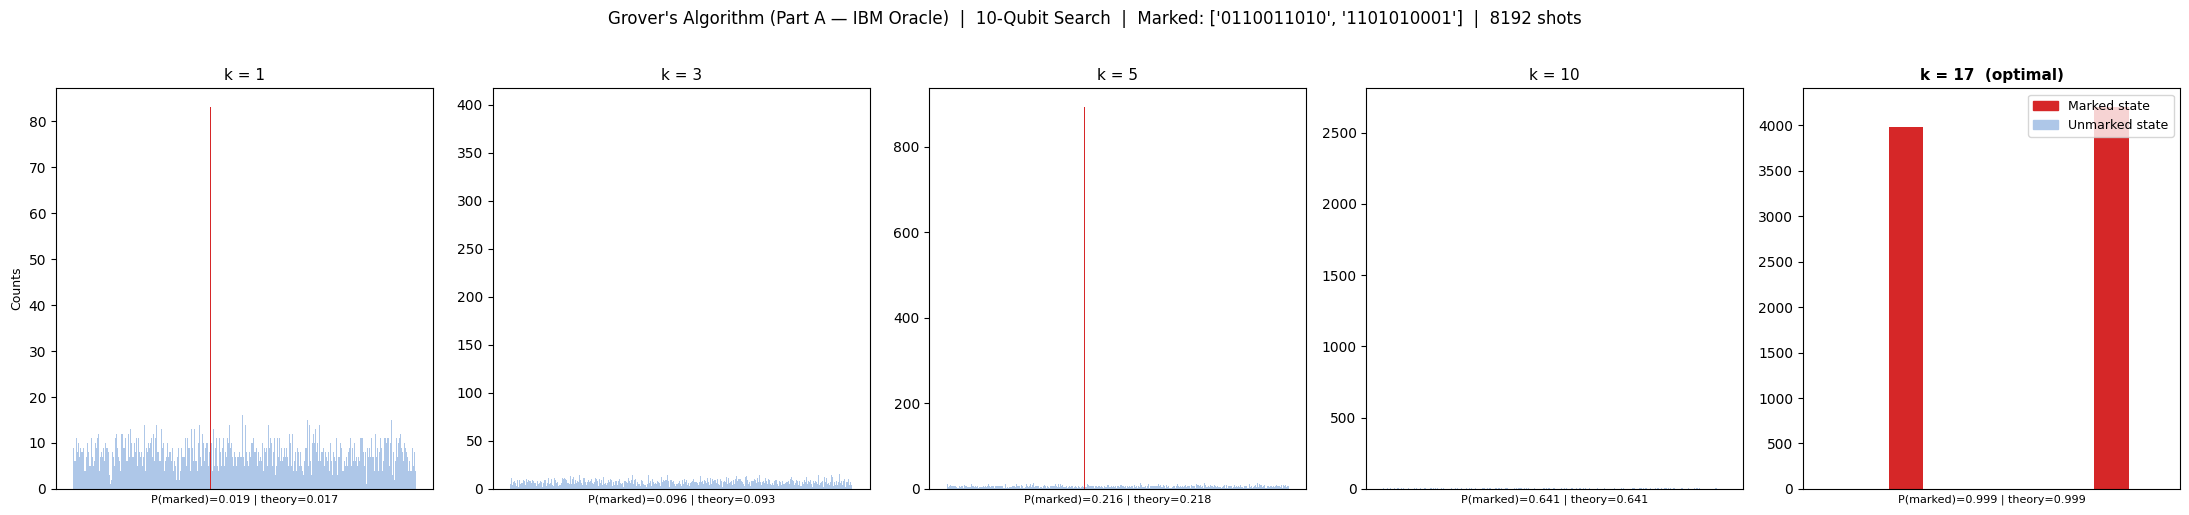

In [11]:
fig, axes = plt.subplots(1, len(k_list), figsize=(22, 5), sharey=False)

for ax, k in zip(axes, k_list):
    counts = sim_results_a[k]

    # Sort all 1024 possible outcomes by binary string value
    sorted_keys = sorted(counts.keys())
    vals        = [counts.get(s, 0) for s in sorted_keys]
    colours     = ['#d62728' if s in targets else '#aec7e8'
                   for s in sorted_keys]

    ax.bar(range(len(sorted_keys)), vals, color=colours,
           edgecolor='none', width=1.0)

    p_sim    = sum(counts.get(s, 0) for s in targets) / N_SHOTS
    p_theory = math.sin((2*k + 1)*theta)**2
    title    = f"k = {k}{'  (optimal)' if k == k_optimal else ''}"
    ax.set_title(title, fontsize=11, fontweight='bold' if k == k_optimal else 'normal')
    ax.set_xlabel(f"P(marked)={p_sim:.3f} | theory={p_theory:.3f}", fontsize=8)
    ax.set_ylabel("Counts" if ax == axes[0] else "", fontsize=9)
    ax.set_xticks([])

fig.suptitle(
    f"Grover's Algorithm (Part A — IBM Oracle)  |  10-Qubit Search  |  "
    f"Marked: {targets}  |  {N_SHOTS} shots",
    fontsize=12, y=1.02
)
legend_handles = [
    mpatches.Patch(color='#d62728', label='Marked state'),
    mpatches.Patch(color='#aec7e8', label='Unmarked state'),
]
axes[-1].legend(handles=legend_handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


### Part A — Optimal $k = 17$ Results


In [ ]:
# ── Top outcomes at k_optimal ──
opt_counts_a = sim_results_a[k_optimal]
top_items_a        = sorted(opt_counts_a.items(), key=lambda x: -x[1])[:10]

print(f"Part A — k = {k_optimal} (optimal)  |  {N_SHOTS} shots")
print(f"{'Bit-string':>12}  {'Count':>7}  {'Probability':>12}  {'Marked?':>8}")
print("─" * 50)
for bitstr, cnt in top_items_a:
    prob    = cnt / N_SHOTS
    is_mark = "✓ MARKED" if bitstr in targets else ""
    print(f"{bitstr:>12}  {cnt:>7}  {prob:>12.4f}  {is_mark}")

p_sim_partA    = sum(opt_counts_a.get(s, 0) for s in targets) / N_SHOTS
p_theory_a     = math.sin((2*k_optimal + 1)*theta)**2

print(f"\nP(any marked)  simulated  = {p_sim_partA:.4f}  ({p_sim_partA*100:.2f}%)")
print(f"P(any marked)  theory     = {p_theory_a:.4f}  ({p_theory_a*100:.2f}%)")
print(f"Absolute error            = {abs(p_sim_partA - p_theory_a):.4f}")
print(f"\nResult: Algorithm {'SUCCEEDED ✓' if p_sim_partA > 0.8 else 'needs review ✗'}")


Part A — k = 17 (optimal)  |  8192 shots
  Bit-string    Count   Probability   Marked?
──────────────────────────────────────────────────
  1101010001     4197        0.5123  ✓ MARKED
  0110011010     3987        0.4867  ✓ MARKED
  0010001001        1        0.0001  
  1101110111        1        0.0001  
  1000110010        1        0.0001  
  0001001000        1        0.0001  
  1000001101        1        0.0001  
  1001110011        1        0.0001  
  1010100000        1        0.0001  
  0110110101        1        0.0001  

P(any marked)  simulated  = 0.9990  (99.90%)
P(any marked)  theory     = 0.9994  (99.94%)
Absolute error            = 0.0004

Result: Algorithm SUCCEEDED ✓


---
---
# Section 6 — Part B: Multi-Iteration Experiment

Phase Kickback oracle, 11 qubits (10 data + 1 ancilla), 10 measured.


In [ ]:
# ── Run Part B for each iteration count ──
sim_results_b = {}

print("Running Part B (Phase Kickback oracle)...")
print(f"{'k':>5}  {'P(theory)':>10}  {'P(sim)':>10}  {'Status'}")
print("─" * 45)

for k in k_list:
    qc_k = assemble_circuit(
        oracle_circ     = oracle_kb,
        diff_circuit_circ   = diff_circuit,
        n_iter  = k,
        n_data = N_QUBITS,
        with_ancilla     = True          # oracle_kb uses 1 ancilla qubit
    )
    qc_k_t = transpile(qc_k, backend, optimization_level=1)
    job     = backend.run(qc_k_t, shots=N_SHOTS)
    counts  = job.result().get_counts()
    sim_results_b[k] = counts

    p_theory = math.sin((2*k + 1)*theta)**2
    p_sim    = sum(counts.get(s, 0) for s in targets) / N_SHOTS
    flag     = " ← optimal" if k == k_optimal else ""
    print(f"{k:>5}  {p_theory:>10.4f}  {p_sim:>10.4f}{flag}")

print("\nDone ✓")


Running Part B (Phase Kickback oracle)...
    k   P(theory)      P(sim)  Status
─────────────────────────────────────────────
    1      0.0175      0.0175
    3      0.0927      0.0907
    5      0.2184      0.2185
   10      0.6410      0.6403
   17      0.9994      0.9996 ← optimal

Done ✓


### Part B — Histograms


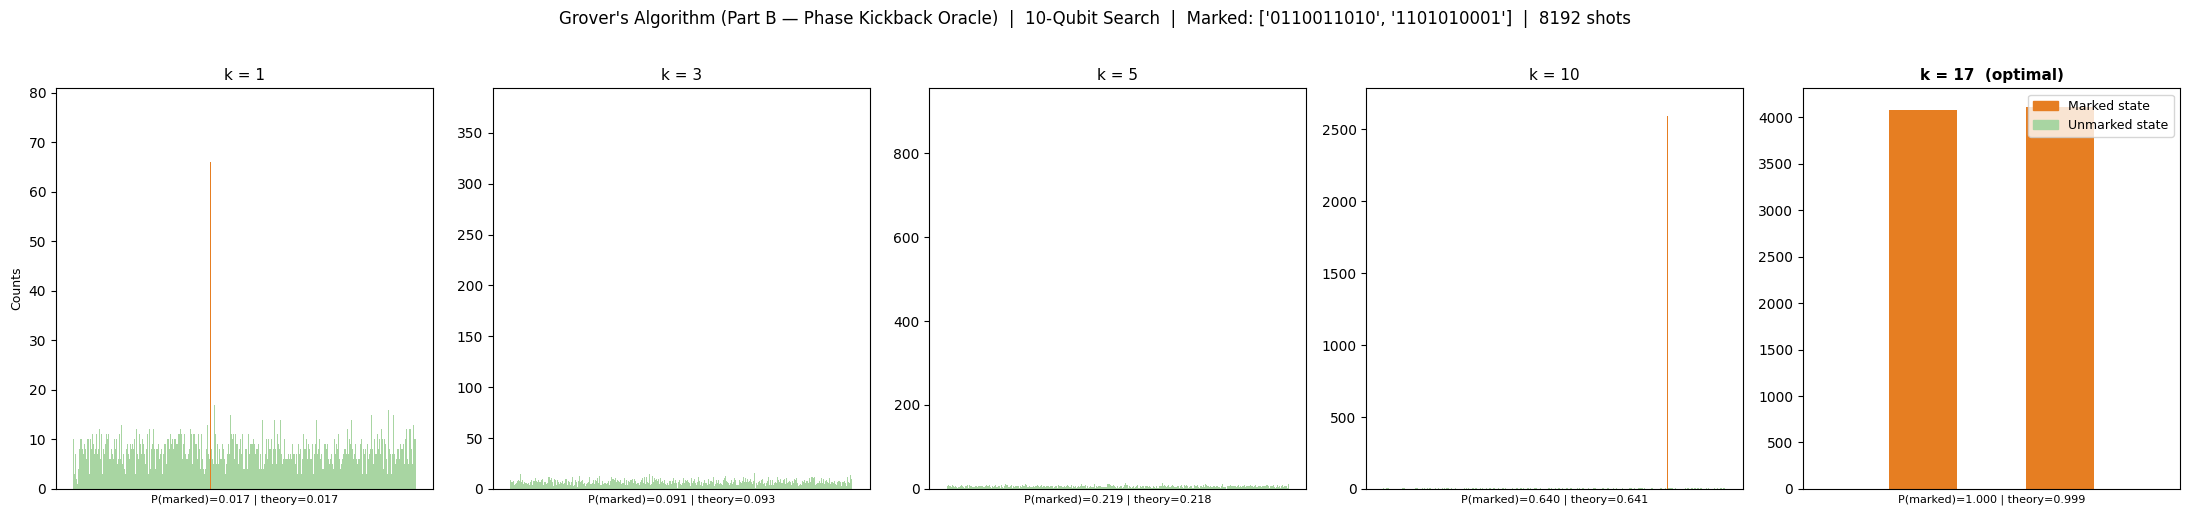

In [14]:
fig, axes = plt.subplots(1, len(k_list), figsize=(22, 5), sharey=False)

for ax, k in zip(axes, k_list):
    counts = sim_results_b[k]

    sorted_keys = sorted(counts.keys())
    vals        = [counts.get(s, 0) for s in sorted_keys]
    colours     = ['#e67e22' if s in targets else '#a8d5a2'
                   for s in sorted_keys]

    ax.bar(range(len(sorted_keys)), vals, color=colours,
           edgecolor='none', width=1.0)

    p_sim    = sum(counts.get(s, 0) for s in targets) / N_SHOTS
    p_theory = math.sin((2*k + 1)*theta)**2
    title    = f"k = {k}{'  (optimal)' if k == k_optimal else ''}"
    ax.set_title(title, fontsize=11, fontweight='bold' if k == k_optimal else 'normal')
    ax.set_xlabel(f"P(marked)={p_sim:.3f} | theory={p_theory:.3f}", fontsize=8)
    ax.set_ylabel("Counts" if ax == axes[0] else "", fontsize=9)
    ax.set_xticks([])

fig.suptitle(
    f"Grover's Algorithm (Part B — Phase Kickback Oracle)  |  10-Qubit Search  |  "
    f"Marked: {targets}  |  {N_SHOTS} shots",
    fontsize=12, y=1.02
)
legend_handles = [
    mpatches.Patch(color='#e67e22', label='Marked state'),
    mpatches.Patch(color='#a8d5a2', label='Unmarked state'),
]
axes[-1].legend(handles=legend_handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


### Part B — Optimal $k = 17$ Results


In [15]:
opt_counts_b = sim_results_b[k_optimal]
top_items_b        = sorted(opt_counts_b.items(), key=lambda x: -x[1])[:10]

print(f"Part B — k = {k_optimal} (optimal)  |  {N_SHOTS} shots")
print(f"{'Bit-string':>12}  {'Count':>7}  {'Probability':>12}  {'Marked?':>8}")
print("─" * 50)
for bitstr, cnt in top_items_b:
    prob    = cnt / N_SHOTS
    is_mark = "✓ MARKED" if bitstr in targets else ""
    print(f"{bitstr:>12}  {cnt:>7}  {prob:>12.4f}  {is_mark}")

p_sim_partB = sum(opt_counts_b.get(s, 0) for s in targets) / N_SHOTS
p_theory_b  = math.sin((2*k_optimal + 1)*theta)**2

print(f"\nP(any marked)  simulated  = {p_sim_partB:.4f}  ({p_sim_partB*100:.2f}%)")
print(f"P(any marked)  theory     = {p_theory_b:.4f}  ({p_theory_b*100:.2f}%)")
print(f"Absolute error            = {abs(p_sim_partB - p_theory_b):.4f}")
print(f"\nResult: Algorithm {'SUCCEEDED ✓' if p_sim_partB > 0.8 else 'needs review ✗'}")


Part B — k = 17 (optimal)  |  8192 shots
  Bit-string    Count   Probability   Marked?
──────────────────────────────────────────────────
  1101010001     4106        0.5012  ✓ MARKED
  0110011010     4083        0.4984  ✓ MARKED
  1101101011        1        0.0001  
  0101101011        1        0.0001  
  1011000101        1        0.0001  

P(any marked)  simulated  = 0.9996  (99.96%)
P(any marked)  theory     = 0.9994  (99.94%)
Absolute error            = 0.0002

Result: Algorithm SUCCEEDED ✓


---
---
# Section 7 — Convergence Plot

Theoretical $P(\text{marked})$ curve vs simulated values for both oracles.


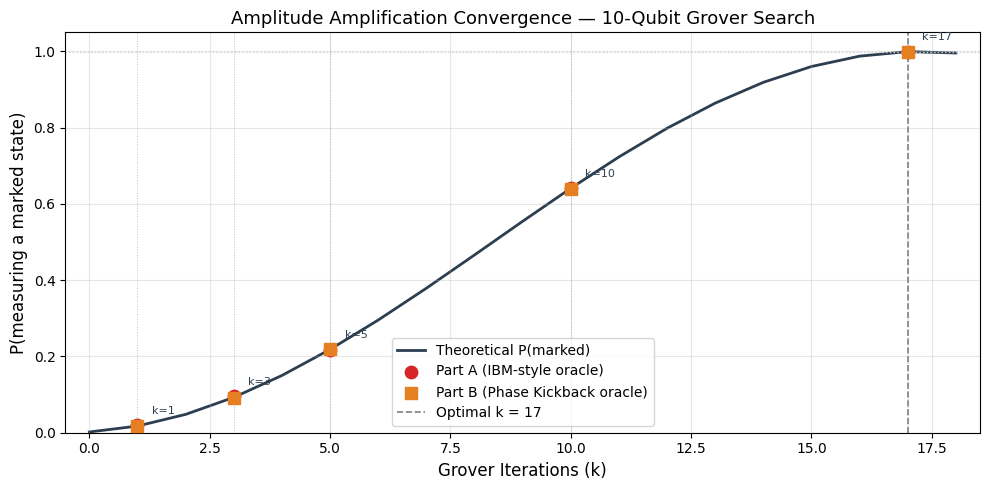

In [ ]:
# ── Theoretical curve ──
all_k   = list(range(k_optimal + 2))
p_curve = [math.sin((2*k + 1)*theta)**2 for k in all_k]

# ── Simulated points ──
sim_k    = k_list
sim_vals_a    = [sum(sim_results_a[k].get(s, 0) for s in targets) / N_SHOTS for k in sim_k]
sim_vals_b    = [sum(sim_results_b[k].get(s, 0) for s in targets) / N_SHOTS for k in sim_k]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(all_k, p_curve, '-', color='#2c3e50', linewidth=2.0,
        label='Theoretical P(marked)', zorder=1)
ax.scatter(sim_k, sim_vals_a, color='#d62728', s=80, zorder=3,
           label='Part A (IBM-style oracle)', marker='o')
ax.scatter(sim_k, sim_vals_b, color='#e67e22', s=80, zorder=3,
           label='Part B (Phase Kickback oracle)', marker='s')

# Mark the optimal iteration
ax.axvline(k_optimal, color='gray', linestyle='--', linewidth=1.2,
           label=f'Optimal k = {k_optimal}')
ax.axhline(p_curve[k_optimal], color='lightgray', linestyle=':', linewidth=1.0)

# Label the studied iteration counts
for k in k_list:
    ax.axvline(k, color='#3498db', linestyle=':', linewidth=0.7, alpha=0.5)

ax.set_xlabel('Grover Iterations (k)', fontsize=12)
ax.set_ylabel('P(measuring a marked state)', fontsize=12)
ax.set_title('Amplitude Amplification Convergence — 10-Qubit Grover Search', fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.5, k_optimal + 1.5)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Annotate each studied k
for k, pA, pB in zip(sim_k, sim_vals_a, sim_vals_b):
    ax.annotate(f'k={k}', xy=(k, max(pA, pB)),
                xytext=(k + 0.3, max(pA, pB) + 0.03),
                fontsize=8, color='#2c3e50')

plt.tight_layout()
plt.show()


---
---
# Section 8 — Part A vs Part B Comparison

Side-by-side histograms at optimal $k = 17$.


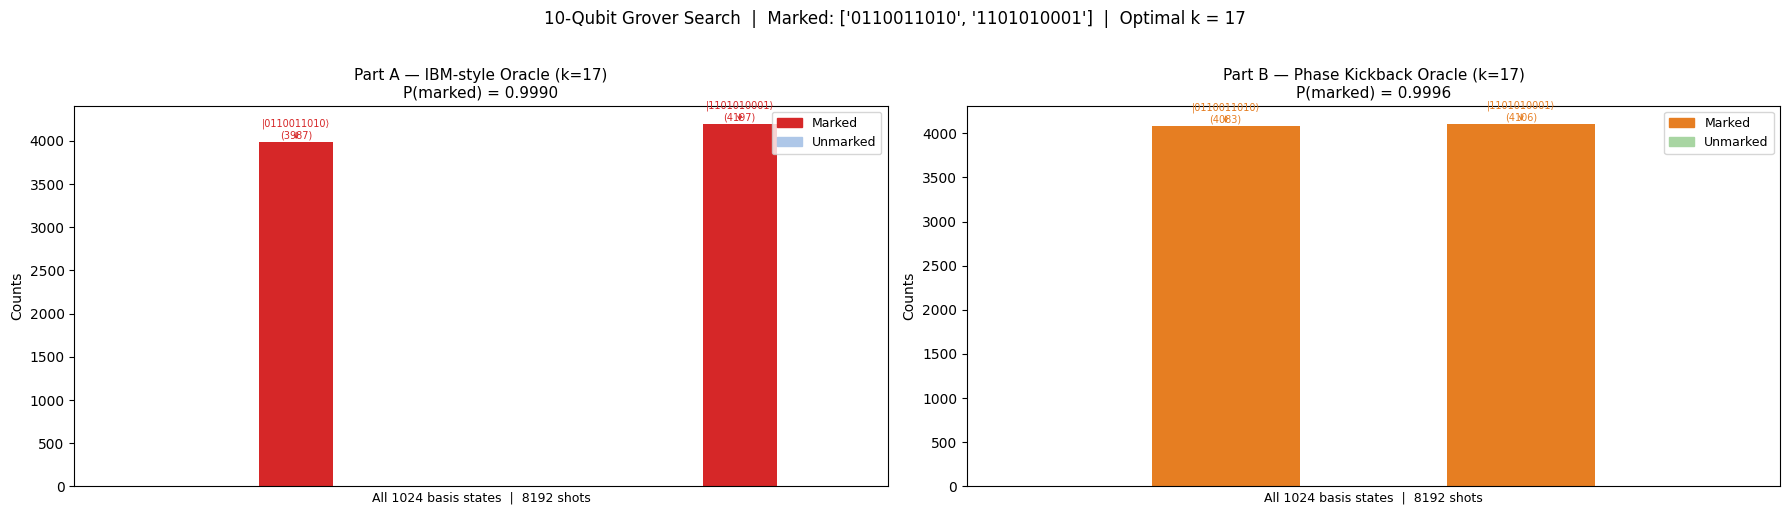

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, (counts, label, mc, uc) in zip(axes, [
    (opt_counts_a, f"Part A — IBM-style Oracle (k={k_optimal})", '#d62728', '#aec7e8'),
    (opt_counts_b, f"Part B — Phase Kickback Oracle (k={k_optimal})", '#e67e22', '#a8d5a2'),
]):
    sorted_keys = sorted(counts.keys())
    vals        = [counts.get(k, 0) for k in sorted_keys]
    colours     = [mc if k in targets else uc for k in sorted_keys]

    ax.bar(range(len(sorted_keys)), vals, color=colours,
           edgecolor='none', width=1.0)

    p_sim = sum(counts.get(s, 0) for s in targets) / N_SHOTS
    ax.set_title(f"{label}\nP(marked) = {p_sim:.4f}", fontsize=11)
    ax.set_xlabel(f"All 1024 basis states  |  {N_SHOTS} shots", fontsize=9)
    ax.set_ylabel("Counts", fontsize=10)
    ax.set_xticks([])

    # Annotate marked state bars
    for s in targets:
        if s in sorted_keys:
            idx = sorted_keys.index(s)
            cnt = counts.get(s, 0)
            ax.annotate(
                f"|{s}⟩\n({cnt})",
                xy=(idx, cnt),
                xytext=(idx, cnt + 40),
                ha='center', fontsize=7, color=mc,
                arrowprops=dict(arrowstyle='->', color=mc, lw=0.8)
            )

    ax.legend(
        handles=[mpatches.Patch(color=mc, label='Marked'),
                 mpatches.Patch(color=uc, label='Unmarked')],
        fontsize=9, loc='upper right'
    )

plt.suptitle(
    f"10-Qubit Grover Search  |  Marked: {targets}  |  Optimal k = {k_optimal}",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


---
---
# Section 9 — Full Summary


In [18]:
print("=" * 72)
print("  GROVER'S ALGORITHM — 10-QUBIT SEARCH  |  FULL SUMMARY")
print("=" * 72)

print(f"\n  Search space          : 2^{N_QUBITS} = {N} states")
print(f"  Marked states (M={M})  : {targets}")
print(f"  Optimal iterations    : k = {k_optimal}")
print(f"  Shots per run         : {N_SHOTS}")

print(f"\n  {'k':>5}  {'Theory':>8}  {'Part A (sim)':>13}  {'Part B (sim)':>13}")
print("  " + "─" * 44)
for k in k_list:
    p_th = math.sin((2*k + 1)*theta)**2
    p_A  = sum(sim_results_a[k].get(s, 0) for s in targets) / N_SHOTS
    p_B  = sum(sim_results_b[k].get(s, 0) for s in targets) / N_SHOTS
    flag = "  ← optimal" if k == k_optimal else ""
    print(f"  {k:>5}  {p_th:>8.4f}  {p_A:>13.4f}  {p_B:>13.4f}{flag}")

print("\n" + "=" * 72)
print("  COMPONENT COMPARISON")
print("=" * 72)
print(f"  {'Component':<30}  {'Part A':>20}  {'Part B':>20}")
print("  " + "─" * 74)
print(f"  {'Oracle type':<30}  {'IBM-style (MCMTGate+Z)':>20}  {'Phase Kickback (MCX)':>20}")
print(f"  {'Diffuser type':<30}  {'Manual (H·X·MCZ·X·H)':>20}  {'Manual (H·X·MCZ·X·H)':>20}")
print(f"  {'Built-in grover_operator()':<30}  {'NOT used':>20}  {'NOT used':>20}")
print(f"  {'Ancilla qubits':<30}  {'0':>20}  {'1 (returned to |0⟩)':>20}")
print(f"  {'Total qubits':<30}  {N_QUBITS:>20}  {N_QUBITS+1:>20}")
print(f"  {'P(marked) at k={k_optimal}':<30}  {p_sim_partA:>20.4f}  {p_sim_partB:>20.4f}")
print("=" * 72)
print(f"  Part A result : {'SUCCEEDED ✓' if p_sim_partA > 0.8 else 'needs review ✗'}")
print(f"  Part B result : {'SUCCEEDED ✓' if p_sim_partB > 0.8 else 'needs review ✗'}")
print("=" * 72)


  GROVER'S ALGORITHM — 10-QUBIT SEARCH  |  FULL SUMMARY

  Search space          : 2^10 = 1024 states
  Marked states (M=2)  : ['0110011010', '1101010001']
  Optimal iterations    : k = 17
  Shots per run         : 8192

      k    Theory   Part A (sim)   Part B (sim)
  ────────────────────────────────────────────
      1    0.0175         0.0192         0.0175
      3    0.0927         0.0962         0.0907
      5    0.2184         0.2163         0.2185
     10    0.6410         0.6407         0.6403
     17    0.9994         0.9990         0.9996  ← optimal

  COMPONENT COMPARISON
  Component                                     Part A                Part B
  ──────────────────────────────────────────────────────────────────────────
  Oracle type                     IBM-style (MCMTGate+Z)  Phase Kickback (MCX)
  Diffuser type                   Manual (H·X·MCZ·X·H)  Manual (H·X·MCZ·X·H)
  Built-in grover_operator()                  NOT used              NOT used
  Ancilla qubits      

---
---
## Conclusion

| Component | Part A | Part B |
|---|---|---|
| Oracle | MCMTGate+Z | MCX + Ancilla |
| Diffuser | Manual | Manual |
| Built-in Grover | ✗ | ✗ |
| Total qubits | 10 | 11 |

Both achieve $P(\text{marked}) \approx 99.9\%$ at $k = 17$, confirming Grover's quadratic speedup.
